###### Patricia Clarji 202500382 | Marie-Lie kadado 202402112

# Diabetes Readmission Prediction

## Objectives
- **Multiclass Classification:** Predict the patient's readmission category (`readmitted`)
- **Regression:** Predict time spent in hospital (`time_in_hospital`)

Dataset:
Diabetes 130-US Hospitals Dataset

### Project Description

Hospital readmissions are costly and may indicate complications in patient care.
The goal of this project is to analyze hospital records of diabetic patients and build machine learning models for:

- **Multiclass classification:** predict the patient's readmission category (`NO`, `>30`, `<30`)
- **Regression:** predict the patient's length of stay in the hospital (`time_in_hospital`)

The dataset contains hospital records of diabetic patients from 1999–2008 across 130 US hospitals.

### Step 1- Import Libraries and Models

In [105]:
import pandas as pd
import numpy as np
import warnings
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display
from matplotlib.patches import Rectangle
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

### Step 2- Load DataSet

In [106]:
#Config:
DATA_PATH = "../data/diabetes.csv"
CLASSIFICATION_TARGET = "readmitted"
REGRESSION_TARGET = "time_in_hospital"
RANDOM_STATE = 42
TARGET= 'readmitted'

In [107]:
# Load dataset
df = pd.read_csv(DATA_PATH, na_values='?', low_memory=False)
columns = df.columns

warnings.filterwarnings("ignore", category=FutureWarning)

In [108]:
# Split Categorical and Numerical Columns
categorical_cols = [
    'race', 'gender', 'age', 'weight',
    'payer_code', 'medical_specialty',
    'diag_1', 'diag_2', 'diag_3',
    'max_glu_serum', 'A1Cresult',
    'metformin', 'repaglinide', 'nateglinide',
    'chlorpropamide', 'glimepiride', 'acetohexamide',
    'glipizide', 'glyburide', 'tolbutamide',
    'pioglitazone', 'rosiglitazone', 'acarbose',
    'miglitol', 'troglitazone', 'tolazamide',
    'examide', 'citoglipton', 'insulin',
    'glyburide-metformin', 'glipizide-metformin',
    'glimepiride-pioglitazone', 'metformin-rosiglitazone',
    'metformin-pioglitazone', 'change', 'diabetesMed',
    'readmitted'
]

numerical_cols = [
    'encounter_id', 'patient_nbr',
    'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
    'time_in_hospital', 'num_lab_procedures', 'num_procedures',
    'num_medications', 'number_outpatient', 'number_emergency',
    'number_inpatient', 'number_diagnoses'
]

### Step 3- Dataset Overview

We inspect the dataset structure, data types, missing values, and descriptive statistics to understand the variables before preprocessing and modeling.


#### 3.1 Head (5 rows)

In [109]:
print("Dataset preview:")
display(df.head(10))


Dataset preview:


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
5,35754,82637451,Caucasian,Male,[50-60),NaN,2,1,2,3,...,No,Steady,No,No,No,No,No,No,Yes,>30
6,55842,84259809,Caucasian,Male,[60-70),NaN,3,1,2,4,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
7,63768,114882984,Caucasian,Male,[70-80),NaN,1,1,7,5,...,No,No,No,No,No,No,No,No,Yes,>30
8,12522,48330783,Caucasian,Female,[80-90),NaN,2,1,4,13,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
9,15738,63555939,Caucasian,Female,[90-100),NaN,3,3,4,12,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


#### 3.2 Info

In [110]:
print("\nDataset info:")
df.info()


Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   encounter_id              101766 non-null  int64
 1   patient_nbr               101766 non-null  int64
 2   race                      99493 non-null   str  
 3   gender                    101766 non-null  str  
 4   age                       101766 non-null  str  
 5   weight                    3197 non-null    str  
 6   admission_type_id         101766 non-null  int64
 7   discharge_disposition_id  101766 non-null  int64
 8   admission_source_id       101766 non-null  int64
 9   time_in_hospital          101766 non-null  int64
 10  payer_code                61510 non-null   str  
 11  medical_specialty         51817 non-null   str  
 12  num_lab_procedures        101766 non-null  int64
 13  num_procedures            101766 non-null  int64
 14  num_medications 

#### 3.3 Missing values

In [111]:
print("\nMissing values per column:")
display(df.isnull().sum().sort_values(ascending=False))


Missing values per column:


weight                      98569
max_glu_serum               96420
A1Cresult                   84748
medical_specialty           49949
payer_code                  40256
race                         2273
diag_3                       1423
diag_2                        358
diag_1                         21
patient_nbr                     0
time_in_hospital                0
admission_source_id             0
num_lab_procedures              0
encounter_id                    0
admission_type_id               0
discharge_disposition_id        0
gender                          0
age                             0
number_inpatient                0
number_emergency                0
number_outpatient               0
num_medications                 0
num_procedures                  0
number_diagnoses                0
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

#### 3.4 Numerical cols

In [112]:
print("\nNumerical summary:")
display(df[numerical_cols].describe().round(2))


Numerical summary:


,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00
mean,1.652016e+08,5.433040e+07,2.02,3.72,5.75,4.40,43.10,1.34,16.02,0.37,0.20,0.64,7.42
std,1.026403e+08,3.869636e+07,1.45,5.28,4.06,2.99,19.67,1.71,8.13,1.27,0.93,1.26,1.93
min,1.252200e+04,1.350000e+02,1.00,1.00,1.00,1.00,1.00,0.00,1.00,0.00,0.00,0.00,1.00
25%,8.496119e+07,2.341322e+07,1.00,1.00,1.00,2.00,31.00,0.00,10.00,0.00,0.00,0.00,6.00
50%,1.523890e+08,4.550514e+07,1.00,1.00,7.00,4.00,44.00,1.00,15.00,0.00,0.00,0.00,8.00
75%,2.302709e+08,8.754595e+07,3.00,4.00,7.00,6.00,57.00,2.00,20.00,0.00,0.00,1.00,9.00
max,4.438672e+08,1.895026e+08,8.00,28.00,25.00,14.00,132.00,6.00,81.00,42.00,76.00,21.00,16.00


#### 3.5 Categorical cols

In [113]:
print("\nCategorical summary:")
for col in categorical_cols:
    print(f"\nColumn: {col}")
    print(df[col].value_counts(dropna=False))
    print("-" * 40)


Categorical summary:

Column: race
race
Caucasian          76099
AfricanAmerican    19210
NaN                 2273
Hispanic            2037
Other               1506
Asian                641
Name: count, dtype: int64
----------------------------------------

Column: gender
gender
Female             54708
Male               47055
Unknown/Invalid        3
Name: count, dtype: int64
----------------------------------------

Column: age
age
[70-80)     26068
[60-70)     22483
[50-60)     17256
[80-90)     17197
[40-50)      9685
[30-40)      3775
[90-100)     2793
[20-30)      1657
[10-20)       691
[0-10)        161
Name: count, dtype: int64
----------------------------------------

Column: weight
weight
NaN          98569
[75-100)      1336
[50-75)        897
[100-125)      625
[125-150)      145
[25-50)         97
[0-25)          48
[150-175)       35
[175-200)       11
>200             3
Name: count, dtype: int64
----------------------------------------

Column: payer_code
payer_code
Na

#### 3.6 Other

In [114]:
print("\nShape of dataset:", df.shape)
print("\nNumber of numeric columns:", len(numerical_cols))
print("\nNumber of categorical columns:", len(categorical_cols))
print("\nClassification target:", CLASSIFICATION_TARGET)
print("\nRegression target:", REGRESSION_TARGET)


Shape of dataset: (101766, 50)

Number of numeric columns: 13

Number of categorical columns: 37

Classification target: readmitted

Regression target: time_in_hospital


### Step 4- EDA Exploratory Data Analysis
In this step, we explore the dataset using visualizations to identify patterns, trends, and relationships between variables. This helps in understanding the data before applying preprocessing and machine learning models.

#### 4.0 Visualization SetUp

In [115]:
sns.set_theme(style="whitegrid", context="notebook")

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

readmit_order = ['NO', '>30', '<30']
age_order = ['[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)',
            '[50-60)', '[60-70)', '[70-80)', '[80-90)', '[90-100)']

num_cols = [
    'time_in_hospital',
    'num_lab_procedures',
    'num_medications',
    'number_outpatient',
    'number_inpatient'
]

utilization_cols = [
    'number_outpatient',
    'number_emergency',
    'number_inpatient'
]

corr_cols = [
    'time_in_hospital', 'num_lab_procedures', 'num_procedures',
    'num_medications', 'number_outpatient', 'number_emergency',
    'number_inpatient', 'number_diagnoses'
]

#### 4.1 Target Variable Analysis
In this section, we analyze the target variables of the project: readmitted for the classification task and time_in_hospital for the regression task. This helps us understand class balance, distribution shape, and potential modeling challenges.

##### A- Readmission Distribution

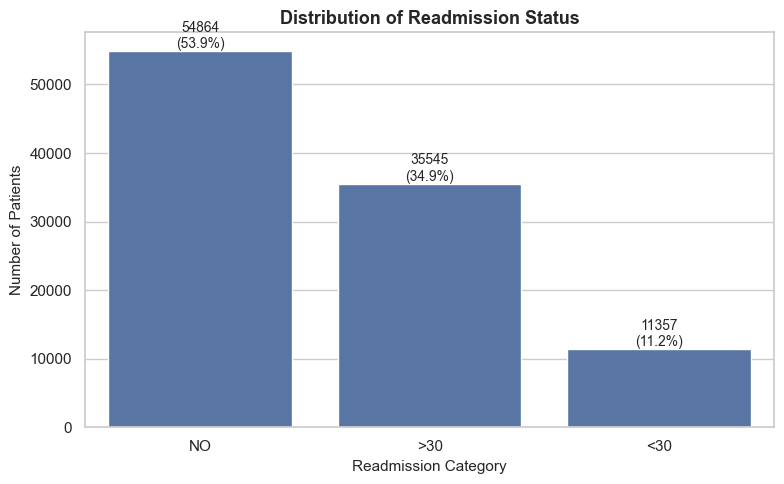

In [116]:
plt.figure(figsize=(8, 5))

ax = sns.countplot(data=df, x='readmitted', order=readmit_order)

total = len(df)
for p in ax.patches:
    if isinstance(p, Rectangle):
        count = int(p.get_height())
        pct = 100 * count / total
        ax.annotate(
            f"{count}\n({pct:.1f}%)",
            (p.get_x() + p.get_width() / 2, p.get_height()),
            ha='center',
            va='bottom',
            fontsize=10
        )

plt.title("Distribution of Readmission Status")
plt.xlabel("Readmission Category")
plt.ylabel("Number of Patients")
plt.tight_layout()
plt.show()

#### Interpretation
Most patients were not readmitted, while the <30 class is the smallest. This shows class imbalance, which matters for the classification task.

#### B- time_in_hospital distribution
Next, we analyze the regression target time_in_hospital to understand its distribution, central tendency, and potential skewness or outliers.

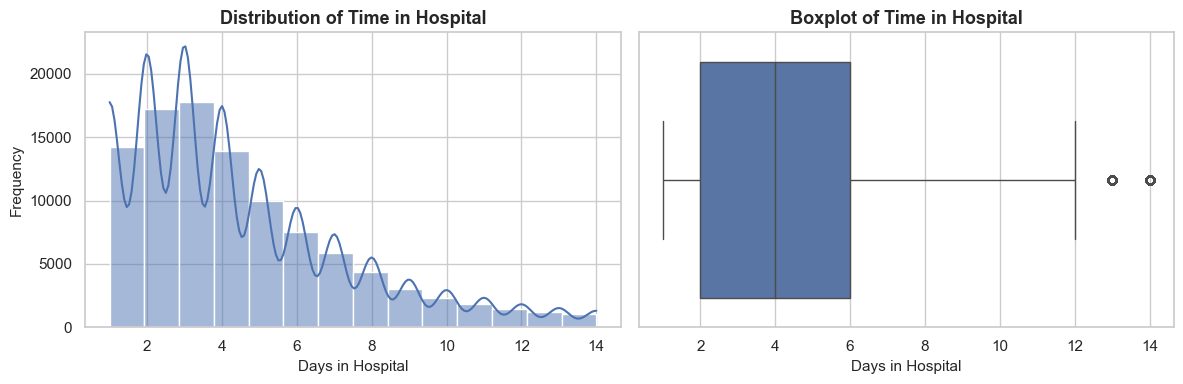

In [117]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(data=df, x='time_in_hospital', bins=14, kde=True, ax=axes[0])
axes[0].set_title("Distribution of Time in Hospital")
axes[0].set_xlabel("Days in Hospital")
axes[0].set_ylabel("Frequency")

sns.boxplot(data=df, x='time_in_hospital', ax=axes[1])
axes[1].set_title("Boxplot of Time in Hospital")
axes[1].set_xlabel("Days in Hospital")

plt.tight_layout()
plt.show()

##### Interpretation

Most hospital stays are short, peaking between 3 and 4 days. The distribution is right-skewed, meaning fewer patients stay for much longer periods. The boxplot also shows outliers, which may represent more severe cases.

#### 4.2 Univariate Analysis

##### A- Numerical Features Distributions

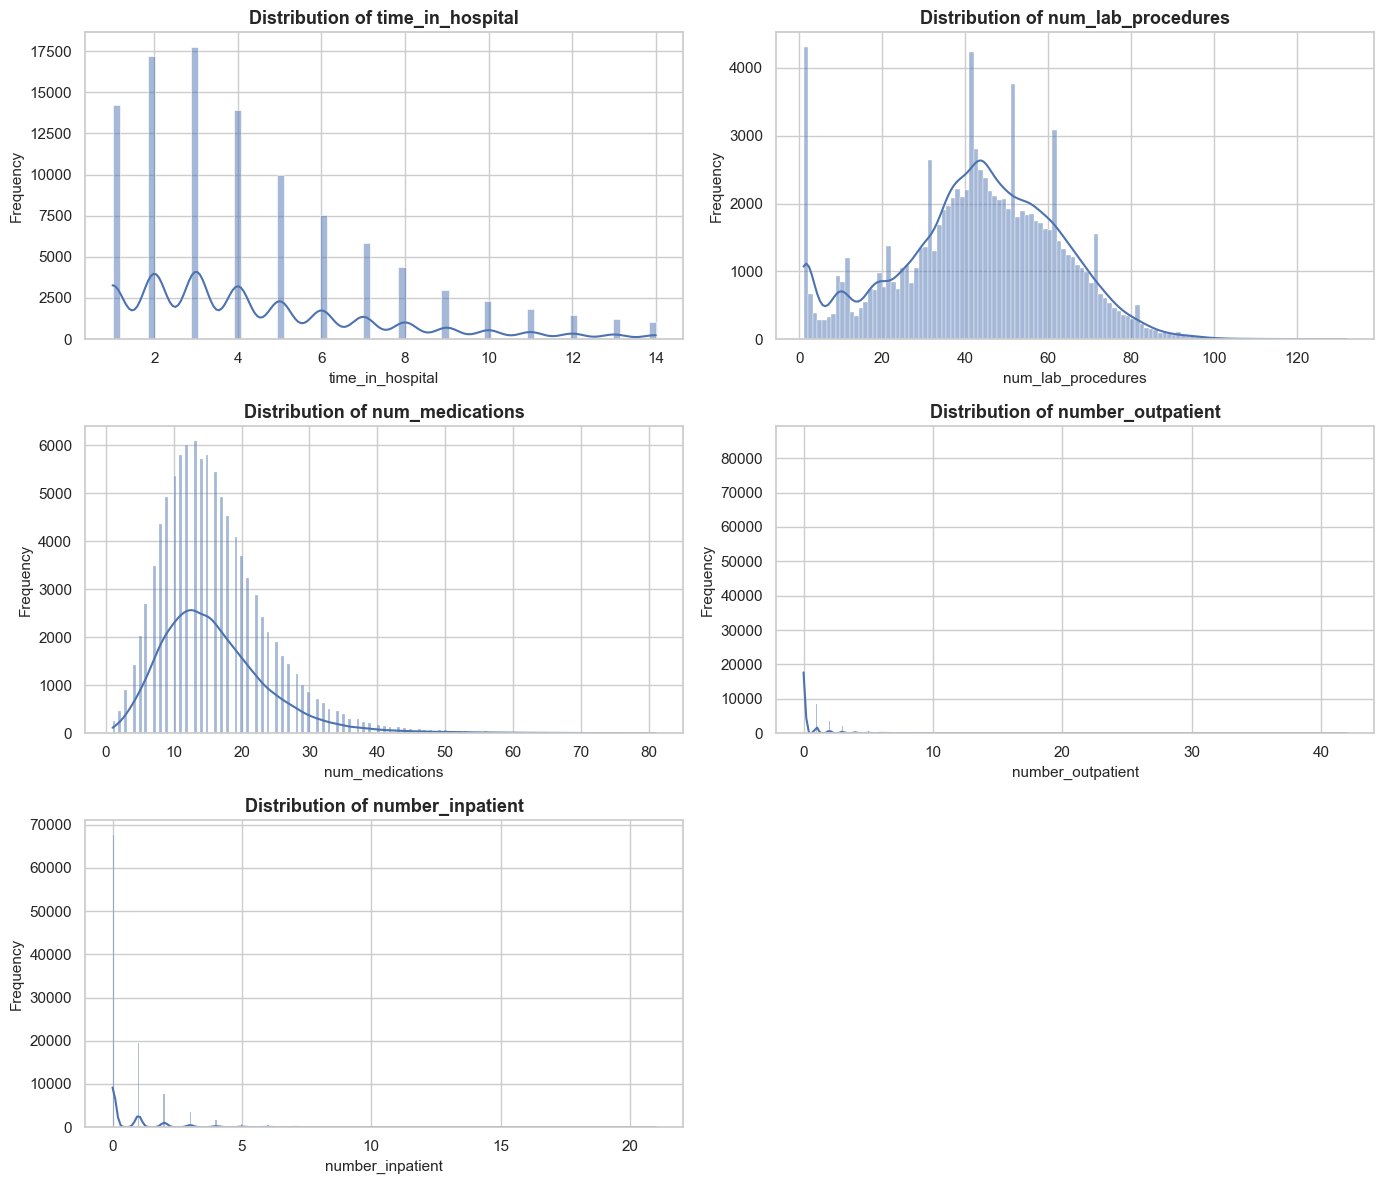

In [118]:
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(data=df, x=col, kde=True, ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")

fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()

#### Interpretation
The numerical features show skewed distributions rather than normal distributions. Variables such as hospital visits, medications, and inpatient history are concentrated at lower values, with fewer patients having very high values.

This suggests that most patients require moderate care, while a smaller group represents more complex or severe cases.

##### B- Numerical Feature Outlier

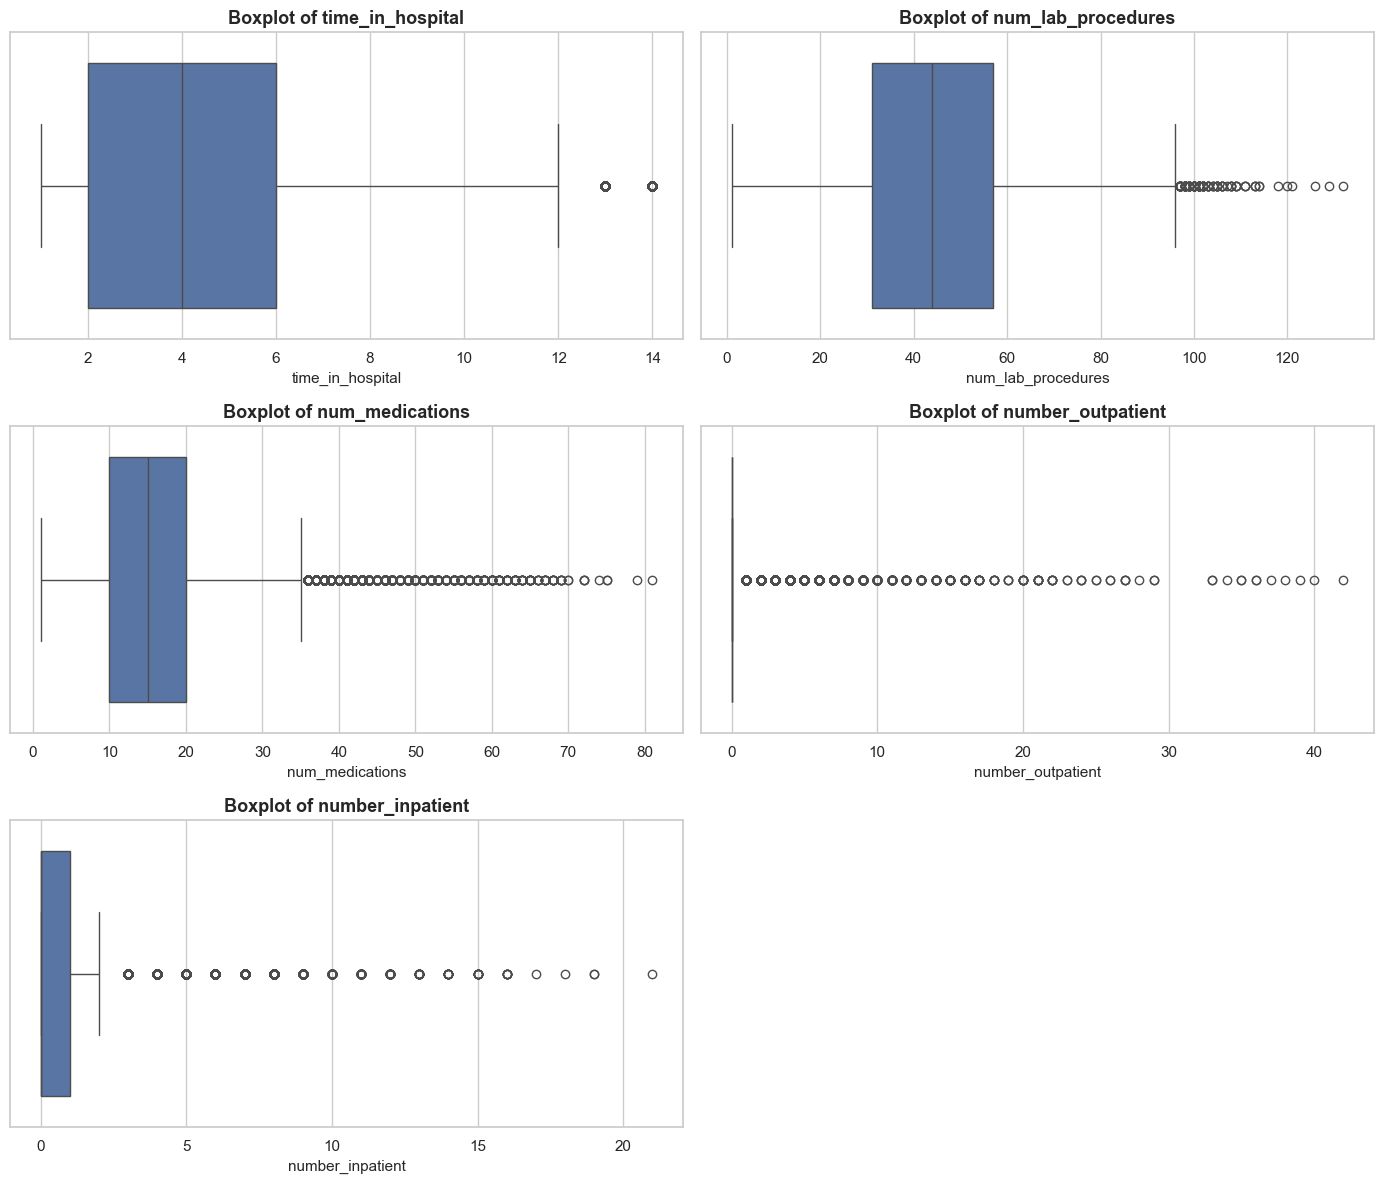

In [119]:
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(data=df, x=col, ax=axes[i])
    axes[i].set_title(f"Boxplot of {col}")
    axes[i].set_xlabel(col)

fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()

#### Interpretation
The boxplots show outliers across several numerical medical features.

In this healthcare context, these outliers may represent real severe patient cases rather than data errors. Therefore, they were not removed, but their presence was considered during preprocessing and model selection.

#### Interpretation

The boxplots show outliers across several numerical medical features.

In this healthcare context, these outliers may represent real severe patient cases rather than data errors. Therefore, they were not removed, but their presence was considered during preprocessing and model selection.

##### C- Categorical Features Distribution

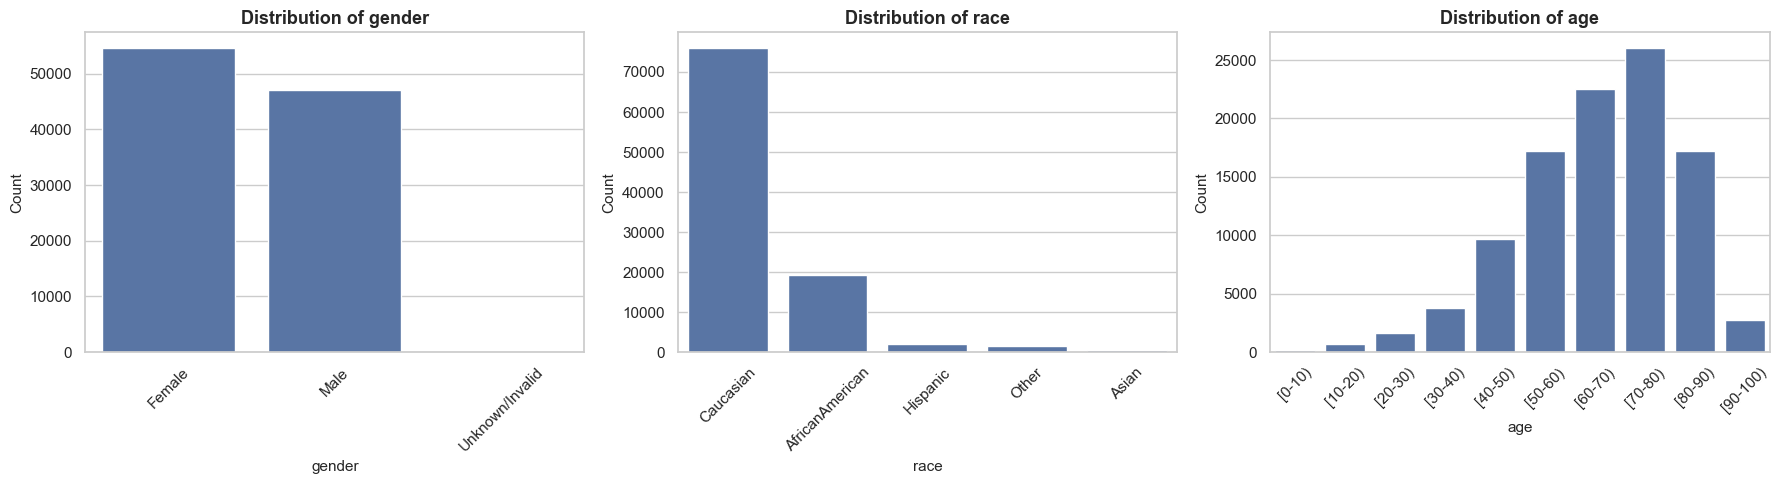

In [120]:
cat_cols = ['gender', 'race', 'age']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    order = age_order if col == 'age' else df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

#### Interpretation
The categorical distributions show that some groups are more represented than others, especially across age and race. This helps identify potential imbalance in categorical variables before encoding.

#### 4.3 Bivariate Analysis: Features vs Readmission

##### A- Demographic Features

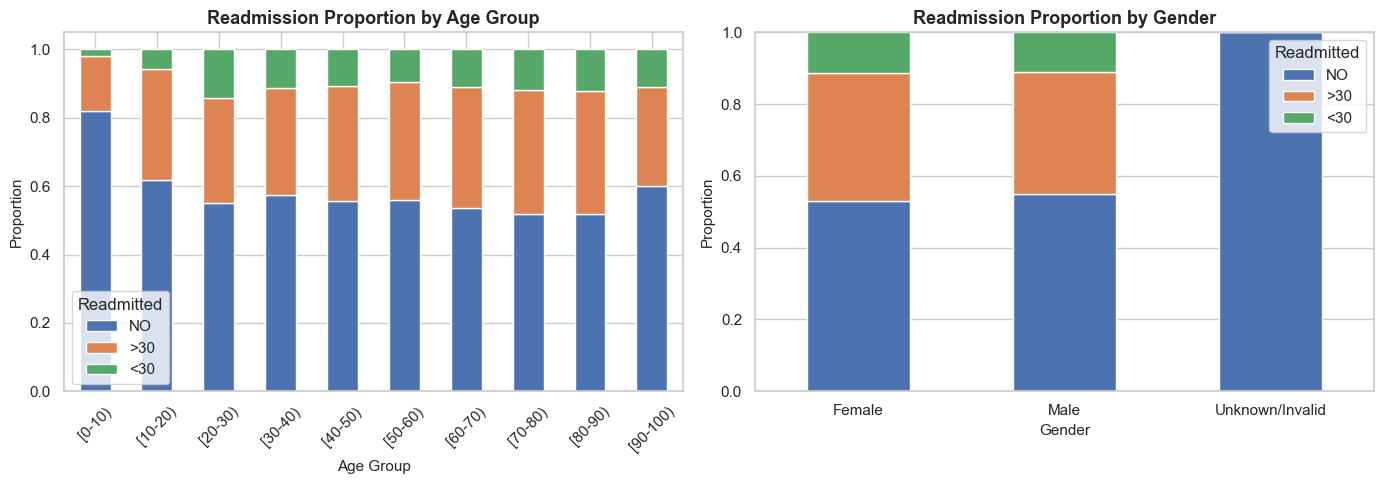

In [121]:
age_readmit = pd.crosstab(df['age'], df['readmitted'], normalize='index').reindex(age_order)
gender_order = df['gender'].value_counts().index
gender_readmit = pd.crosstab(df['gender'], df['readmitted'], normalize='index').reindex(gender_order)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

age_readmit[readmit_order].plot(kind='bar', stacked=True, ax=axes[0])
axes[0].set_title("Readmission Proportion by Age Group")
axes[0].set_xlabel("Age Group")
axes[0].set_ylabel("Proportion")
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(title='Readmitted')

gender_readmit[readmit_order].plot(kind='bar', stacked=True, ax=axes[1])
axes[1].set_title("Readmission Proportion by Gender")
axes[1].set_xlabel("Gender")
axes[1].set_ylabel("Proportion")
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Readmitted')

plt.tight_layout()
plt.show()

#### Interpretation
Older age groups show higher readmission proportions, suggesting age may be an important predictor. Gender differences are minimal, indicating that gender alone may not strongly influence readmission.

##### B- Clinical Features

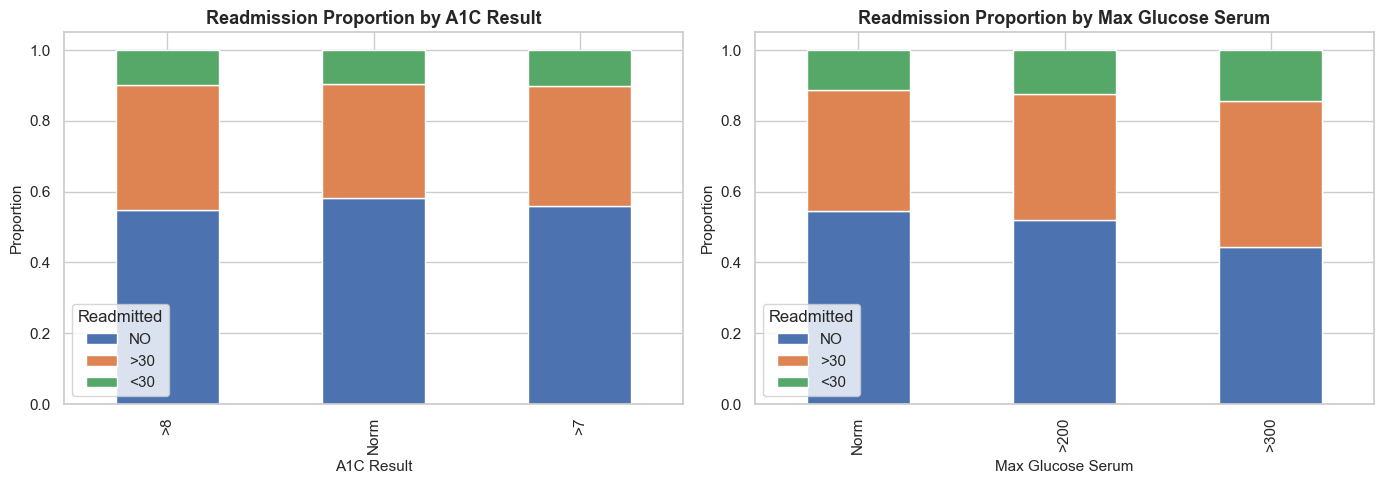

In [122]:
a1c_order = df['A1Cresult'].value_counts().index
a1c_readmit = pd.crosstab(df['A1Cresult'], df['readmitted'], normalize='index').reindex(a1c_order)

glu_order = df['max_glu_serum'].value_counts().index
glu_readmit = pd.crosstab(df['max_glu_serum'], df['readmitted'], normalize='index').reindex(glu_order)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

a1c_readmit[readmit_order].plot(kind='bar', stacked=True, ax=axes[0])
axes[0].set_title("Readmission Proportion by A1C Result")
axes[0].set_xlabel("A1C Result")
axes[0].set_ylabel("Proportion")
axes[0].legend(title='Readmitted')

glu_readmit[readmit_order].plot(kind='bar', stacked=True, ax=axes[1])
axes[1].set_title("Readmission Proportion by Max Glucose Serum")
axes[1].set_xlabel("Max Glucose Serum")
axes[1].set_ylabel("Proportion")
axes[1].legend(title='Readmitted')

plt.tight_layout()
plt.show()

#### Interpretation
Patients with abnormal A1C and glucose results tend to have higher readmission proportions. This suggests that poor glycemic control is associated with increased readmission risk.

#### C- Hospital Utilization Features

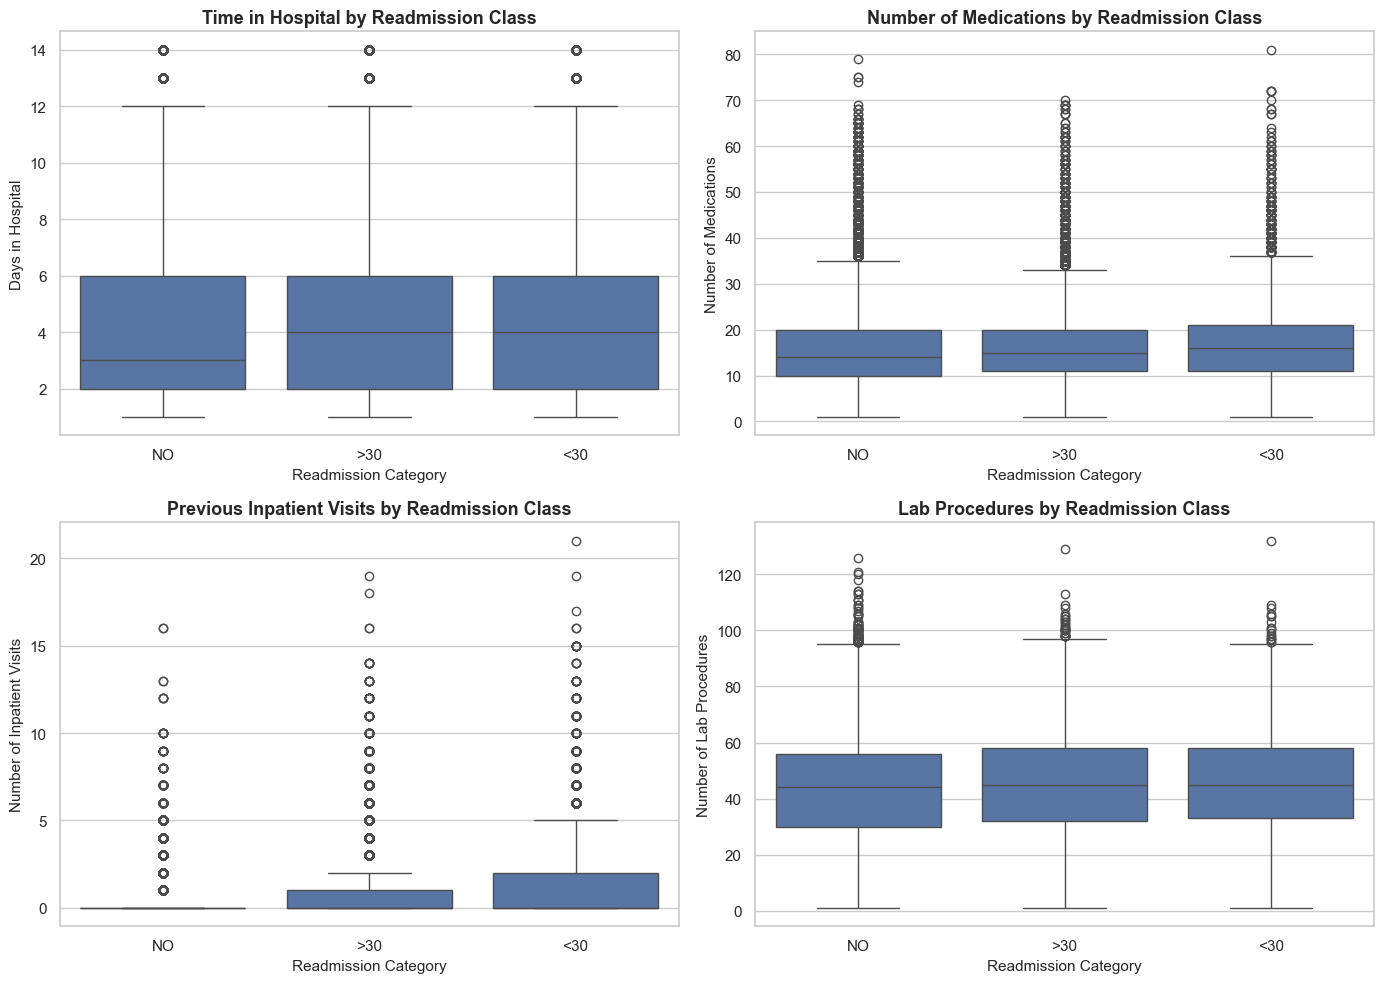

In [123]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

sns.boxplot(data=df, x='readmitted', y='time_in_hospital', order=readmit_order, ax=axes[0])
axes[0].set_title("Time in Hospital by Readmission Class")
axes[0].set_xlabel("Readmission Category")
axes[0].set_ylabel("Days in Hospital")

sns.boxplot(data=df, x='readmitted', y='num_medications', order=readmit_order, ax=axes[1])
axes[1].set_title("Number of Medications by Readmission Class")
axes[1].set_xlabel("Readmission Category")
axes[1].set_ylabel("Number of Medications")

sns.boxplot(data=df, x='readmitted', y='number_inpatient', order=readmit_order, ax=axes[2])
axes[2].set_title("Previous Inpatient Visits by Readmission Class")
axes[2].set_xlabel("Readmission Category")
axes[2].set_ylabel("Number of Inpatient Visits")

sns.boxplot(data=df, x='readmitted', y='num_lab_procedures', order=readmit_order, ax=axes[3])
axes[3].set_title("Lab Procedures by Readmission Class")
axes[3].set_xlabel("Readmission Category")
axes[3].set_ylabel("Number of Lab Procedures")

plt.tight_layout()
plt.show()

#### Interpretation
Patients who are readmitted tend to have longer hospital stays, use more medications, and have more previous inpatient visits. These patterns suggest that hospital utilization and clinical complexity are strongly related to readmission risk.

#### 4.4. Missingness Overview

##### A- Missing percentage by feature

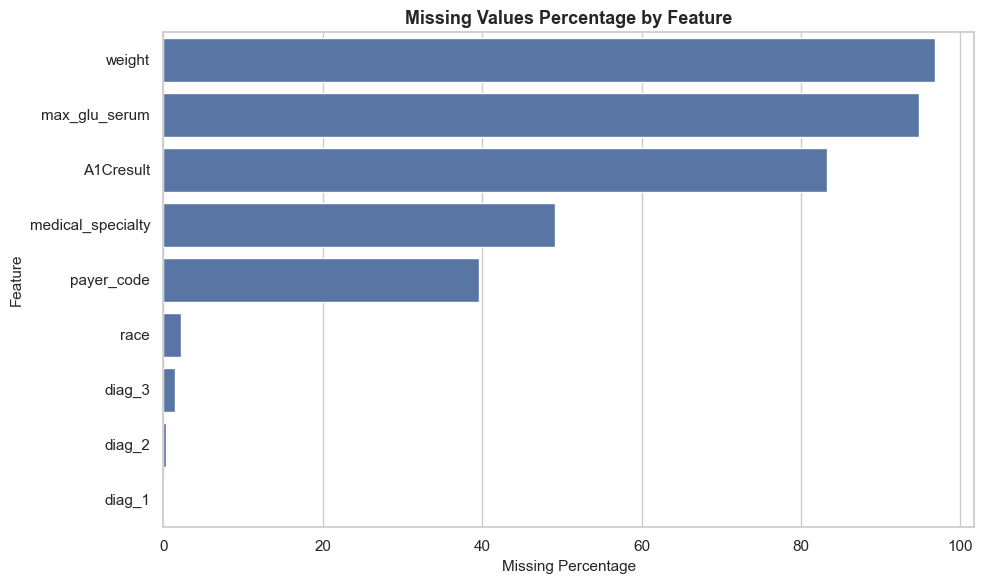

In [124]:
missing_pct = (df.isnull().mean() * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

plt.figure(figsize=(10, 6))
sns.barplot(x=missing_pct.values, y=missing_pct.index)
plt.title("Missing Values Percentage by Feature")
plt.xlabel("Missing Percentage")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

##### B- Missingness heatmap for columns with missing values

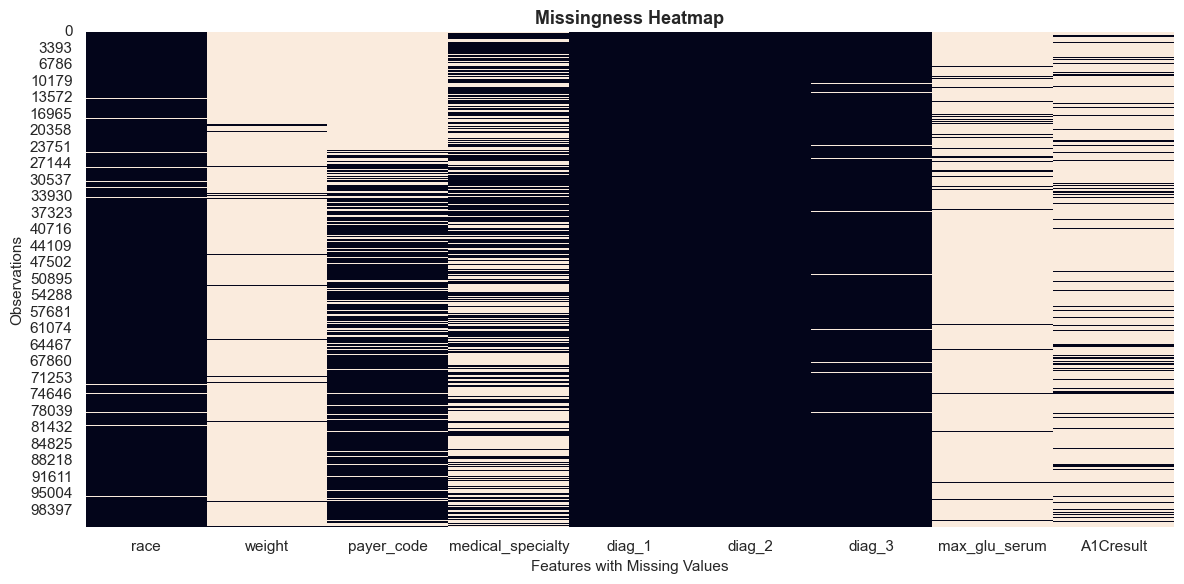

In [125]:
missing_cols = df.columns[df.isnull().any()].tolist()

plt.figure(figsize=(12, 6))
sns.heatmap(df[missing_cols].isnull(), cbar=False)
plt.title("Missingness Heatmap")
plt.xlabel("Features with Missing Values")
plt.ylabel("Observations")
plt.tight_layout()
plt.show()

#### Interpretation
The missingness heatmap shows that missing values are concentrated in specific columns rather than being spread evenly across the dataset.

Features such as weight, payer_code, and medical_specialty contain large amounts of missing data, supporting the decision to remove them during preprocessing. Other missing values were handled using imputation methods based on feature type.

#### 4.5 Correlation and Numerical Relationships

##### A- Correlation heatmap

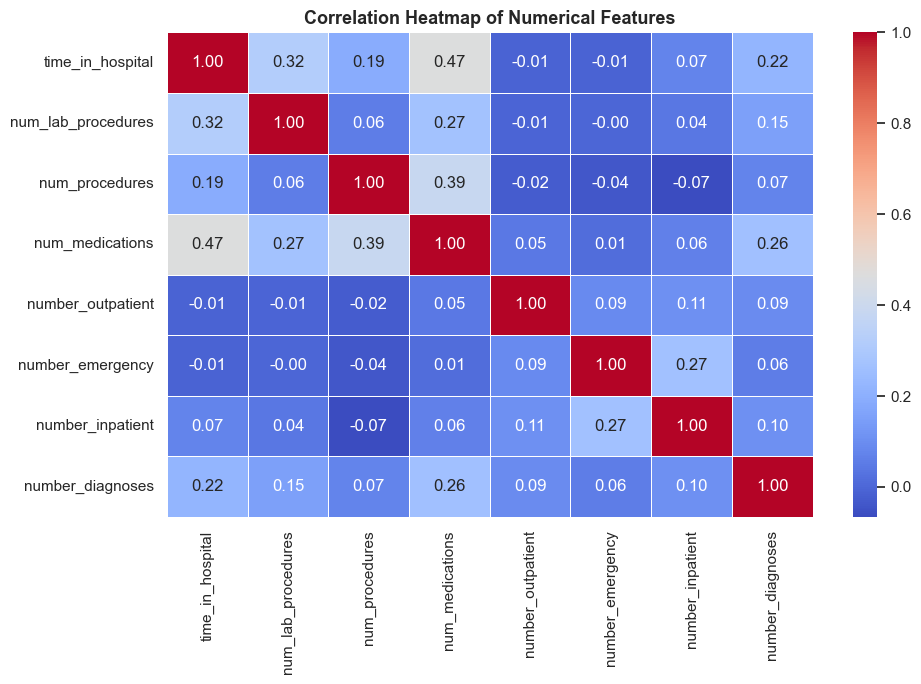

In [126]:
corr = df[corr_cols].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

#### Interpretation

The correlation heatmap shows moderate relationships between several numerical variables, especially features related to hospital utilization and treatment intensity.

No extremely high correlations are observed, suggesting that severe multicollinearity is not a major issue among the selected numerical features.

##### B- Selected numerical relationship plots

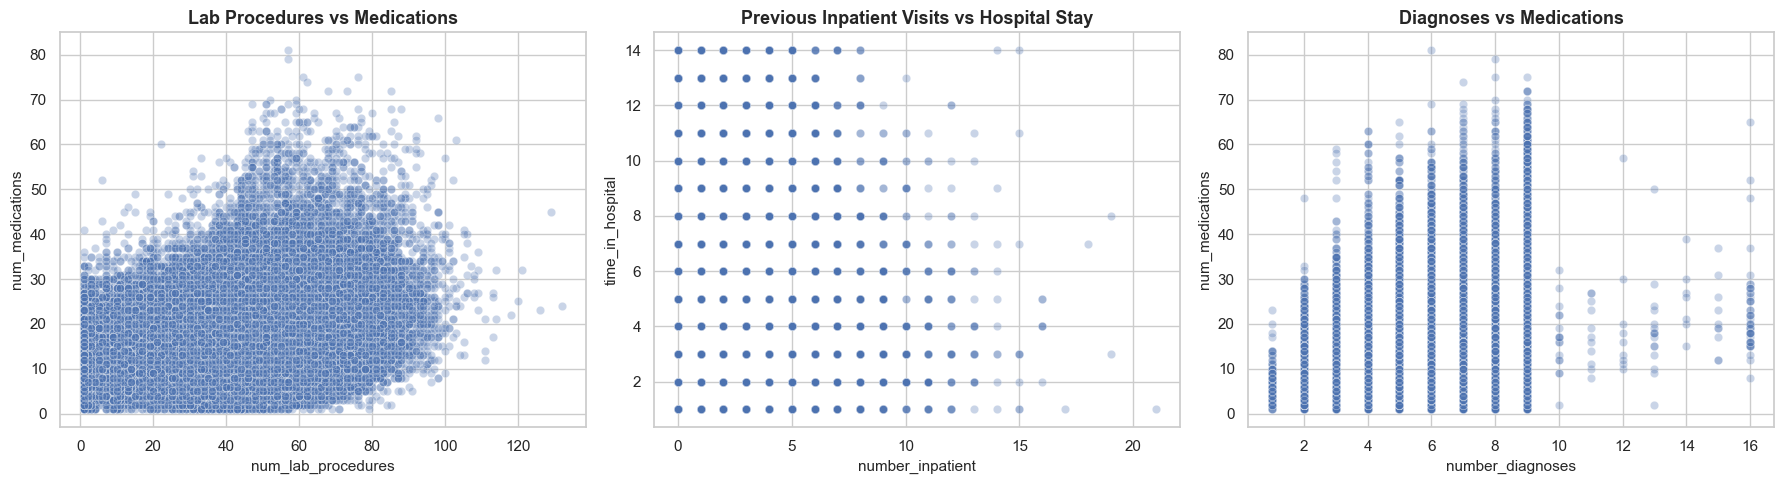

In [127]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(data=df, x='num_lab_procedures', y='num_medications', alpha=0.3, ax=axes[0])
axes[0].set_title("Lab Procedures vs Medications")

sns.scatterplot(data=df, x='number_inpatient', y='time_in_hospital', alpha=0.3, ax=axes[1])
axes[1].set_title("Previous Inpatient Visits vs Hospital Stay")

sns.scatterplot(data=df, x='number_diagnoses', y='num_medications', alpha=0.3, ax=axes[2])
axes[2].set_title("Diagnoses vs Medications")

plt.tight_layout()
plt.show()

#### Interpretation

The scatterplots show moderate positive relationships between several numerical features. In particular, patients with more diagnoses and lab procedures tend to receive more medications. While these relationships are not extremely strong, they indicate that combinations of these variables may be useful for predicting readmission. No severe linear relationships are observed, suggesting that multicollinearity may not be a major issue.

#### 4.6 Additional Categorical Analysis

##### Readmission rate by top race categories

<Figure size 800x500 with 0 Axes>

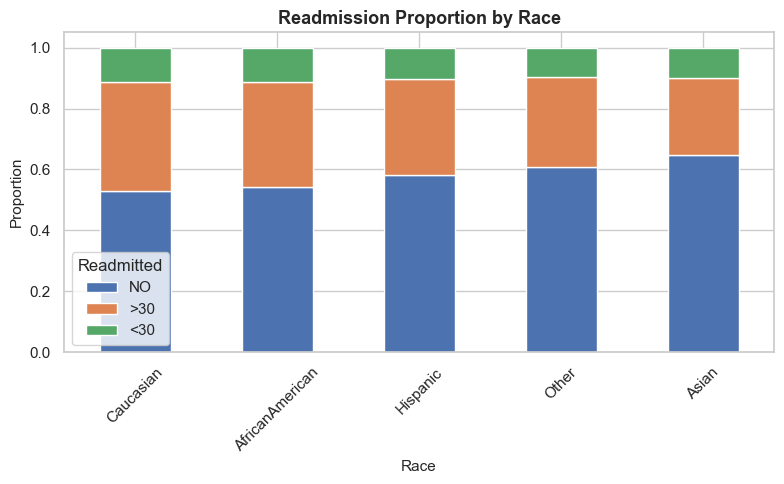

In [128]:
top_race = df['race'].value_counts().index
race_readmit = pd.crosstab(df['race'], df['readmitted'], normalize='index').reindex(top_race)

plt.figure(figsize=(8, 5))
race_readmit[readmit_order].plot(kind='bar', stacked=True)
plt.title("Readmission Proportion by Race")
plt.xlabel("Race")
plt.ylabel("Proportion")
plt.xticks(rotation=45)
plt.legend(title='Readmitted')
plt.tight_layout()
plt.show()

##### Readmission rate by admission type

<Figure size 800x500 with 0 Axes>

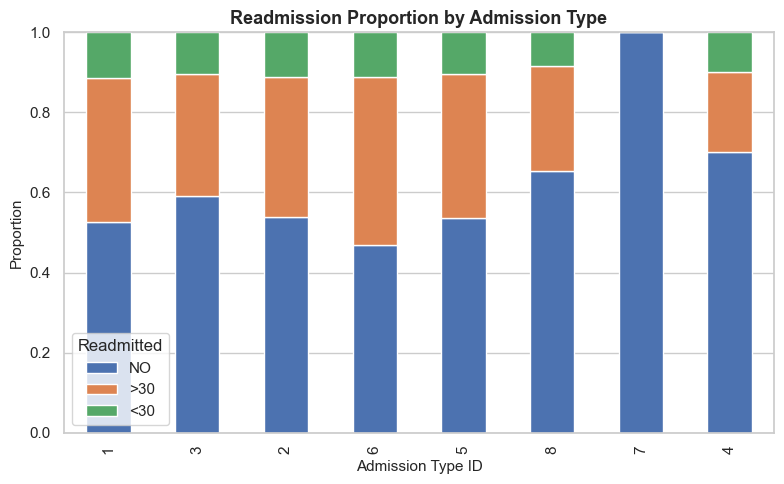

In [129]:
admission_order = df['admission_type_id'].value_counts().index
admission_readmit = pd.crosstab(df['admission_type_id'], df['readmitted'], normalize='index').reindex(admission_order)

plt.figure(figsize=(8, 5))
admission_readmit[readmit_order].plot(kind='bar', stacked=True)
plt.title("Readmission Proportion by Admission Type")
plt.xlabel("Admission Type ID")
plt.ylabel("Proportion")
plt.legend(title='Readmitted')
plt.tight_layout()
plt.show()

### Step 5- Data Preprocessing

Data preprocessing prepares the dataset for machine learning by handling
missing values, removing irrelevant features, encoding categorical variables,
and scaling numerical features.

#### Keep only the last encounter per patient
To avoid patient-level data leakage, only the last encounter for each patient was kept.

This prevents the same patient from appearing multiple times in the dataset and makes model evaluation more realistic and generalizable. The last encounter was selected because it represents the most recent available clinical information.

In [130]:
df = df.sort_values(by=['patient_nbr', 'encounter_id'])
df = df.drop_duplicates(subset='patient_nbr', keep='last')

# Drop columns
df = df.drop(['encounter_id', 'patient_nbr'], axis=1)

#### 5.1 Missing Values Check

In [131]:
print("Missing values per column:")
display(df.isnull().sum().sort_values(ascending=False))

Missing values per column:


weight                      68671
max_glu_serum               68041
A1Cresult                   59120
medical_specialty           34525
payer_code                  30085
race                         1878
diag_3                       1146
diag_2                        290
diag_1                         17
time_in_hospital                0
num_lab_procedures              0
admission_source_id             0
admission_type_id               0
discharge_disposition_id        0
gender                          0
age                             0
number_inpatient                0
number_emergency                0
number_outpatient               0
num_medications                 0
num_procedures                  0
number_diagnoses                0
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide                   0
glipizide                       0
glyburide     

### Outlier Handling

Although outliers were observed in several numerical features, they were not removed.

In healthcare datasets, extreme values often represent real clinical conditions rather than errors.

Removing them could result in loss of important information, especially for severe patient cases.

Therefore, outliers were retained to preserve data integrity.

##### 5.1.1 Handling missing values

Different imputation methods were used depending on the nature of each feature:

- **Categorical medical variables (diagnosis, lab tests):**
  - Missing values were treated as meaningful categories (e.g., "Missing", "NotMeasured") since absence of measurement carries information.
  - Rare race categories such as Asian and Hispanic were grouped into the "Other" category to reduce sparsity and improve model generalization. This helps prevent the model from overfitting to categories with very few observations.

- **Medication features:**
  Missing values were replaced with "No", assuming the medication was not prescribed.

- **Numerical features:**
  - Median was used for skewed distributions to reduce the impact of outliers.
  - Zero was used for count-based features where missing implies no occurrences.

- **Target variable:**
  Rows with missing target values were removed to ensure valid supervised learning.

This approach preserves domain meaning and avoids introducing bias.

In [132]:
# 1. Remove rows with missing target
df = df.dropna(subset=['readmitted'])

# 2. Diagnosis columns -> keep missing as category
missing_category_cols = ['race', 'diag_1', 'diag_2', 'diag_3']

for col in missing_category_cols:
    df[col] = df[col].fillna('Missing').astype(str)

# Combine rare race categories into "Other"
df['race'] = df['race'].replace({
    'Asian': 'Other',
    'Hispanic': 'Other'
})


# 3. Lab result columns -> missing means not measured
lab_cols = ['max_glu_serum', 'A1Cresult']
for col in lab_cols:
    df[col] = df[col].fillna('NotMeasured')

# 4. Medication columns -> missing means No
medication_cols = [
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride',
    'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone',
    'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide',
    'examide', 'citoglipton', 'insulin', 'glyburide-metformin',
    'glipizide-metformin', 'glimepiride-pioglitazone',
    'metformin-rosiglitazone', 'metformin-pioglitazone'
]

for col in medication_cols:
    df[col] = df[col].fillna('No')

# 5. Binary columns
df['change'] = df['change'].fillna('No')
df['diabetesMed'] = df['diabetesMed'].fillna('No')

# 6. Hospital code columns should be categorical
coded_cols = ['admission_type_id', 'discharge_disposition_id', 'admission_source_id']
for col in coded_cols:
    df[col] = df[col].astype(str)

# 7. Numeric columns
median_cols = [
    'time_in_hospital',
    'num_lab_procedures',
    'num_procedures',
    'num_medications',
    'number_diagnoses'
]

zero_cols = [
    'number_outpatient',
    'number_emergency',
    'number_inpatient'
]

for col in median_cols:
    df[col] = df[col].fillna(df[col].median())

for col in zero_cols:
    df[col] = df[col].fillna(0)

print("Remaining missing values:")
display(df.isnull().sum().sort_values(ascending=False).head(20))

Remaining missing values:


weight                      68671
medical_specialty           34525
payer_code                  30085
race                            0
admission_type_id               0
discharge_disposition_id        0
gender                          0
age                             0
time_in_hospital                0
admission_source_id             0
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                          0
diag_2                          0
diag_3                          0
number_diagnoses                0
dtype: int64

#### Correlation Analysis

In [133]:
df_corr = df.copy()

# Encode target
target_map = {'NO': 0, '>30': 1, '<30': 2}
df_corr['readmitted_num'] = df_corr['readmitted'].map(target_map)

results = []

for col in df_corr.columns:
    
    if col in ['readmitted', 'readmitted_num']:
        continue

    try:
        # Numeric columns
        if pd.api.types.is_numeric_dtype(df_corr[col]):
            corr = df_corr[col].corr(df_corr['readmitted_num'])
        
        # Categorical columns
        else:
            temp = pd.get_dummies(df_corr[col], drop_first=True)
            corr = temp.corrwith(df_corr['readmitted_num']).abs().mean()
        
        results.append((col, corr))
    
    except Exception as e:
        print(f"Skipping column {col} بسبب error: {e}")

# Convert to DataFrame
corr_df = pd.DataFrame(results, columns=['Feature', 'Correlation'])

# Drop NaN correlations
corr_df = corr_df.dropna()

# Sort
corr_df = corr_df.sort_values(by='Correlation', ascending=False)

# Show
print("Correlation per original feature:\n")
display(corr_df)

Correlation per original feature:



,Feature,Correlation
15,number_inpatient,0.184387
19,number_diagnoses,0.105419
10,num_lab_procedures,0.086152
14,number_emergency,0.081089
13,number_outpatient,0.074303
46,diabetesMed,0.048421
12,num_medications,0.048244
7,time_in_hospital,0.046962
3,weight,0.035828
4,admission_type_id,0.032951


The correlation analysis was used to examine the relationship between each original feature and the readmission target.

The strongest associations were found in hospital utilization features, especially number_inpatient, number_emergency, and number_outpatient. This suggests that previous healthcare usage is an important indicator of future readmission risk.

Features such as time_in_hospital, num_medications, and num_lab_procedures showed weaker but still meaningful relationships, reflecting treatment intensity and patient condition.

Demographic features and many individual medication variables showed lower individual correlation. However, they were not removed solely based on correlation because non-linear models such as Random Forest may still use them through interactions with other variables.

Overall, the analysis supports the idea that readmission is influenced mainly by prior hospital utilization and clinical complexity.

#### 5.2 Drop Columns with Too Many Missing Values

In [134]:
cols_to_drop = ['weight', 'payer_code', 'medical_specialty']
df.drop(columns=cols_to_drop, inplace=True)

print("Dataset shape after dropping columns:", df.shape)

Dataset shape after dropping columns: (71518, 45)


Features with excessive missing data (weight, payer_code, medical_specialty) were dropped, as they provide limited useful information and may negatively affect model performance.

#### 5.3 Remove Duplicate Rows

In [135]:
print("Duplicate rows before:", df.duplicated().sum())

df.drop_duplicates(inplace=True)

print("Duplicate rows after:", df.duplicated().sum())
print("Dataset shape after removing duplicates:", df.shape)

Duplicate rows before: 0
Duplicate rows after: 0
Dataset shape after removing duplicates: (71518, 45)


#### 5.4 Clean Invalid Gender Values

In [136]:
print("Gender values before cleaning:")
print(df['gender'].value_counts(dropna=False))

df = df[df['gender'].isin(['Male', 'Female'])]

print("\nGender values after cleaning:")
print(df['gender'].value_counts(dropna=False))

Gender values before cleaning:
gender
Female             38023
Male               33492
Unknown/Invalid        3
Name: count, dtype: int64

Gender values after cleaning:
gender
Female    38023
Male      33492
Name: count, dtype: int64


#### 5.5 Check Multiclass Target Distribution

In [137]:
print("Readmission classes:")
print(df['readmitted'].value_counts(dropna=False))

Readmission classes:
readmitted
NO     54371
>30    13920
<30     3224
Name: count, dtype: int64


#### 5.6 Convert Age Groups to Numeric Values

In [138]:
age_map = {
    '[0-10)': 5, '[10-20)': 15, '[20-30)': 25, '[30-40)': 35,
    '[40-50)': 45, '[50-60)': 55, '[60-70)': 65, '[70-80)': 75,
    '[80-90)': 85, '[90-100)': 95
}

df['age_numeric'] = df['age'].map(age_map)

display(df[['age', 'age_numeric']].head())

,age,age_numeric
4780,[50-60),55
5827,[50-60),55
67608,[80-90),85
17494,[80-90),85
2270,[30-40),35


#### 5.7 Group Diagnosis Codes into ICD-9 Categories
The diagnosis variables (`diag_1`, `diag_2`, and `diag_3`) were grouped into broader ICD-9 medical categories.

This reduces the number of unique diagnosis codes, lowers noise, and improves model stability while preserving useful clinical meaning.


Reference for the ICD-9 codes: https://www.aapc.com/codes/icd9-codes-range/?srsltid=AfmBOorChMmlu7I3XsQZ4f8JLVbjNI0l-tjSmXFUV7l3ceI6sevjYv8O

In [139]:
def map_diagnosis(diag):
    try:
        diag = str(diag)

        # Keep missing diagnosis values as Missing
        if diag == 'Missing':
            return 'Missing'

        # Handle special ICD-9 codes
        if diag.startswith('V') or diag.startswith('E'):
            return 'Other'

        diag = float(diag)

        if 1 <= diag < 140:
            return 'Infection'
        elif 140 <= diag < 240:
            return 'Neoplasm'
        elif 240 <= diag < 280:
            return 'Endocrine'
        elif 280 <= diag < 290:
            return 'Blood'
        elif 290 <= diag < 320:
            return 'Mental'
        elif 320 <= diag < 390:
            return 'Nervous'
        elif 390 <= diag < 460:
            return 'Circulatory'
        elif 460 <= diag < 520:
            return 'Respiratory'
        elif 520 <= diag < 580:
            return 'Digestive'
        elif 580 <= diag < 630:
            return 'Genitourinary'
        elif 630 <= diag < 680:
            return 'Pregnancy'
        elif 680 <= diag < 710:
            return 'Skin'
        elif 710 <= diag < 740:
            return 'Musculoskeletal'
        elif 740 <= diag < 760:
            return 'Congenital'
        elif 760 <= diag < 780:
            return 'Perinatal'
        elif 780 <= diag < 800:
            return 'Symptoms'
        elif 800 <= diag < 1000:
            return 'Injury'
        else:
            return 'Other'

    except:
        return 'Other'
    
for col in ['diag_1', 'diag_2', 'diag_3']:
    df[col] = df[col].apply(map_diagnosis)


#### 5.8 Final Missing Values Check

In [140]:
print("Remaining missing values:")
display(df.isnull().sum().sort_values(ascending=False).head(20))

Remaining missing values:


race                        0
gender                      0
age                         0
admission_type_id           0
discharge_disposition_id    0
admission_source_id         0
time_in_hospital            0
num_lab_procedures          0
num_procedures              0
num_medications             0
number_outpatient           0
number_emergency            0
number_inpatient            0
diag_1                      0
diag_2                      0
diag_3                      0
number_diagnoses            0
max_glu_serum               0
A1Cresult                   0
metformin                   0
dtype: int64

#### 5.9 Preprocessing Summary

In [141]:
print("Final dataset shape:", df.shape)
print("Remaining missing values total:", df.isnull().sum().sum())

Final dataset shape: (71515, 46)
Remaining missing values total: 0


#### 5.10 Feature engineering
New features were created to summarize patient healthcare usage and treatment intensity.

- `total_visits` combines inpatient, emergency, and outpatient visits.
- `total_procedures` combines lab procedures and medical procedures.
- `num_diagnoses` summarizes the number of available diagnosis categories.

These engineered features provide additional signals related to patient severity and may improve both classification and regression performance.

In [142]:
# 1. Total visits
df['total_visits'] = (df['number_inpatient'] + df['number_emergency'] + df['number_outpatient'])

# 2. Total procedures
df['total_procedures'] = (df['num_procedures'] + df['num_lab_procedures'])

# 3. Number of diagnoses
df['num_diagnosis_categories'] = (
    df[['diag_1', 'diag_2', 'diag_3']] != 'Missing'
).sum(axis=1)

#### 5.11 Anomaly Detection

In [ ]:
# Prepare data
X_anomaly = df.drop(columns=['readmitted'])
X_anomaly = X_anomaly.select_dtypes(include=['int64', 'float64'])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_anomaly)

# Apply Isolation Forest
iso = IsolationForest(contamination=0.05, random_state=42)
df['anomaly'] = iso.fit_predict(X_scaled)

#check results
#print(df['anomaly'].value_counts())

# Remove anomalies (overwrite df)
df = df[df['anomaly'] == 1]

# Clean up
df = df.drop(columns=['anomaly'])

### Step-6- Multiclass Classification
We now build models to predict the readmission category (readmitted).

#### 6.0 Import Classification Libraries

In [177]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#### 6.1 Prepare Features and Target

In this step:
    Separate features (X) and target (y)
    Ensure the target is correctly defined
    Prepare the dataset for modeling

In [178]:
y_clf = df["readmitted"]
X_clf = df.drop(columns=["readmitted", "readmitted_binary"], errors='ignore')

print("Feature matrix shape:", X_clf.shape)
print("Target shape:", y_clf.shape)
print("\nTarget distribution:")
print(y_clf.value_counts())

Feature matrix shape: (64542, 48)
Target shape: (64542,)

Target distribution:
readmitted
NO     50671
>30    11325
<30     2546
Name: count, dtype: int64


#### 6.2 Train-Test Split
We split the dataset into training and testing sets.
Since this is classification, we use stratification to preserve class balance.

In [179]:
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf,
    y_clf,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_clf
)

print("Training set size:", X_train_clf.shape)
print("Testing set size:", X_test_clf.shape)

Training set size: (51633, 48)
Testing set size: (12909, 48)


#### 6.3 Encoding Categorical Features

Categorical variables were encoded using One-Hot Encoding since they do not have an inherent ordinal relationship.

This allows models to treat each category independently.

However, due to the large number of categorical features, this significantly increases dimensionality, which can impact computational efficiency.

In [180]:
categorical_features = X_train_clf.select_dtypes(include=["object"]).columns.tolist()

X_train_clf_encoded = pd.get_dummies(
    X_train_clf,
    columns=categorical_features,
    drop_first=True
)

X_test_clf_encoded = pd.get_dummies(
    X_test_clf,
    columns=categorical_features,
    drop_first=True
)

X_train_clf_encoded, X_test_clf_encoded = X_train_clf_encoded.align(
    X_test_clf_encoded,
    join="left",
    axis=1,
    fill_value=0
)

print("Encoded training shape:", X_train_clf_encoded.shape)
print("Encoded testing shape:", X_test_clf_encoded.shape)

C:\Users\User\AppData\Local\Temp\ipykernel_30924\1434856128.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train_clf.select_dtypes(include=["object"]).columns.tolist()


Encoded training shape: (51633, 174)
Encoded testing shape: (12909, 174)


#### 6.4 Feature Scaling

In [181]:
scaler_clf = StandardScaler(with_mean=False)

X_train_clf_scaled = scaler_clf.fit_transform(X_train_clf_encoded)
X_test_clf_scaled = scaler_clf.transform(X_test_clf_encoded)

print("Feature scaling completed.")

Feature scaling completed.


#### 6.5 Train and evaluate Multiple Classification Models

In this step, we train several classification models and compare their performance.

We will use:

- K-Nearest Neighbors (KNN)
- Support Vector Machine (Linear SVM)
- Decision Tree
- Random Forest
- Naive Bayes

Logistic Regression was considered as a baseline model, but it was excluded because it required a long training time on the high-dimensional one-hot encoded dataset.

##### Evaluate model definition

In [182]:
def run_evaluate_model(model, model_name, X_train, X_test, y_train, y_test):

    print(f"\n--- {model_name} ---")

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred) * 100
    f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

    print(f"Accuracy: {acc:.2f}%")
    print(f"Weighted F1 Score: {f1:.4f}")
    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred, zero_division=0))

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

    return acc, f1, y_pred

#### Logistic Regression
Logistic Regression was considered as a baseline model, but it was excluded from the final comparison because it required a long training time on the high-dimensional one-hot encoded dataset.

####  KNN
KNN is sensitive to high-dimensional data, and performance decreases after one-hot encoding due to sparsity.


--- KNN ---
Accuracy: 78.50%
Weighted F1 Score: 0.6940

Classification Report:

              precision    recall  f1-score   support

         <30       0.00      0.00      0.00       509
         >30       0.44      0.01      0.02      2265
          NO       0.79      1.00      0.88     10135

    accuracy                           0.79     12909
   macro avg       0.41      0.34      0.30     12909
weighted avg       0.70      0.79      0.69     12909



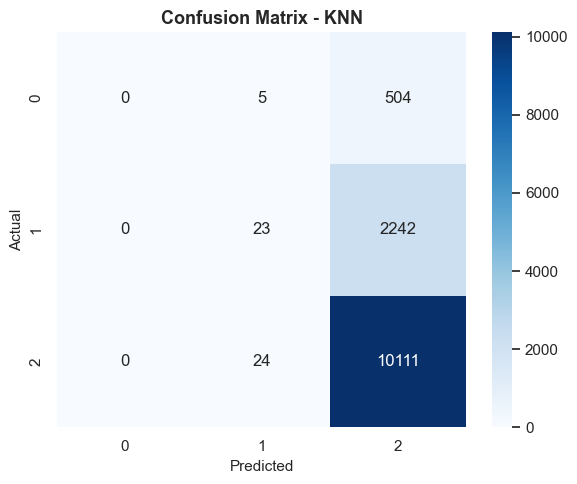

In [183]:
knn_model = KNeighborsClassifier(
    n_neighbors=15,
    weights="distance",
    n_jobs=-1
)

acc_knn, f1_knn, y_pred_knn = run_evaluate_model(
    knn_model,
    "KNN",
    X_train_clf_scaled,
    X_test_clf_scaled,
    y_train_clf,
    y_test_clf
)

#### Linear SVM


--- Linear SVM ---
Accuracy: 78.51%
Weighted F1 Score: 0.6906

Classification Report:

              precision    recall  f1-score   support

         <30       0.00      0.00      0.00       509
         >30       0.00      0.00      0.00      2265
          NO       0.79      1.00      0.88     10135

    accuracy                           0.79     12909
   macro avg       0.26      0.33      0.29     12909
weighted avg       0.62      0.79      0.69     12909



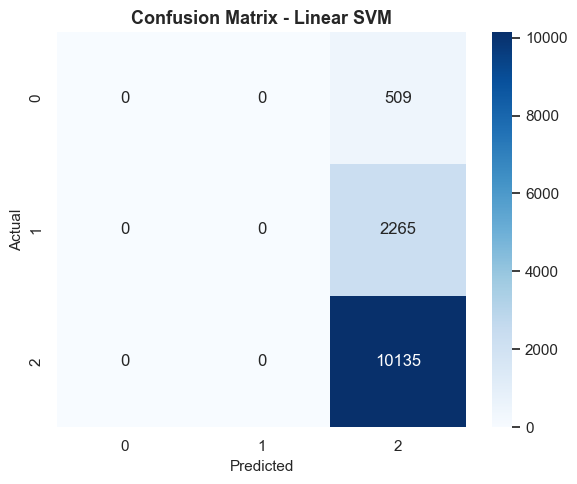

In [184]:
svm_model = LinearSVC(
    class_weight="balanced",
    random_state=RANDOM_STATE,
    max_iter=3000
)

acc_svm, f1_svm, y_pred_svm = run_evaluate_model(
    svm_model,
    "Linear SVM",
    X_train_clf_scaled,
    X_test_clf_scaled,
    y_train_clf,
    y_test_clf
)

#### Decision Tree


--- Decision Tree ---
Accuracy: 48.14%
Weighted F1 Score: 0.5456

Classification Report:

              precision    recall  f1-score   support

         <30       0.06      0.26      0.10       509
         >30       0.23      0.53      0.32      2265
          NO       0.86      0.48      0.62     10135

    accuracy                           0.48     12909
   macro avg       0.39      0.42      0.35     12909
weighted avg       0.72      0.48      0.55     12909



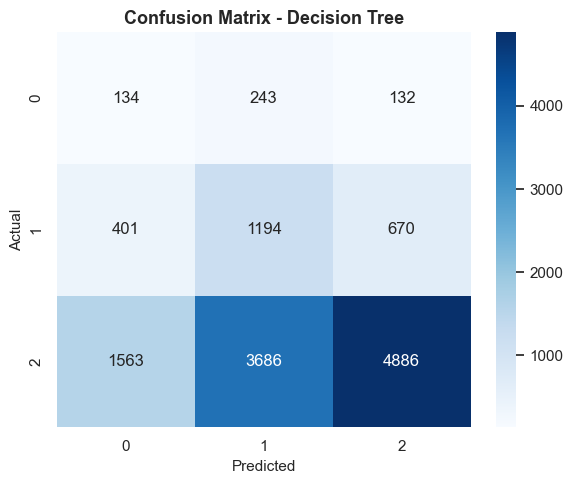

In [185]:
tree_model = DecisionTreeClassifier(
    max_depth=18,
    min_samples_split=10,
    min_samples_leaf=3,
    class_weight="balanced",
    random_state=RANDOM_STATE
)

acc_tree, f1_tree, y_pred_tree = run_evaluate_model(
    tree_model,
    "Decision Tree",
    X_train_clf_encoded,
    X_test_clf_encoded,
    y_train_clf,
    y_test_clf
)

#### Random Forest


--- Random Forest ---
Accuracy: 75.02%
Weighted F1 Score: 0.7300

Classification Report:

              precision    recall  f1-score   support

         <30       0.19      0.03      0.06       509
         >30       0.36      0.30      0.33      2265
          NO       0.82      0.89      0.85     10135

    accuracy                           0.75     12909
   macro avg       0.46      0.41      0.41     12909
weighted avg       0.72      0.75      0.73     12909



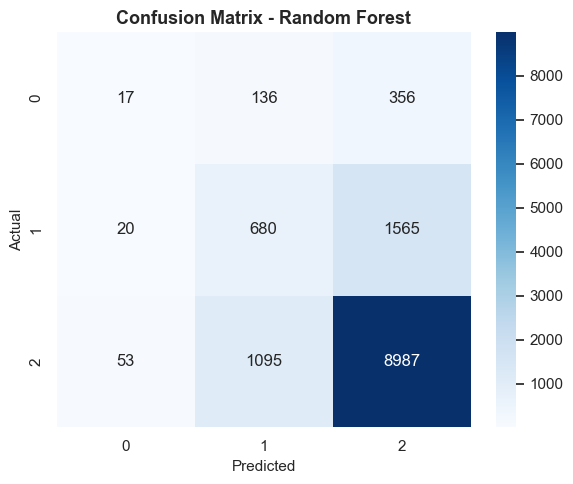

In [186]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=10,
    min_samples_leaf=3,
    class_weight="balanced",
    n_jobs=-1,
    random_state=RANDOM_STATE
)

acc_rf, f1_rf, y_pred_rf = run_evaluate_model(
    rf_model,
    "Random Forest",
    X_train_clf_encoded,
    X_test_clf_encoded,
    y_train_clf,
    y_test_clf
)

#### Random Forest Feature Importance

,Feature,Importance
1,num_lab_procedures,0.071787
10,total_procedures,0.071088
3,num_medications,0.066885
0,time_in_hospital,0.049838
7,number_diagnoses,0.041040
2,num_procedures,0.035696
8,age_numeric,0.031084
9,total_visits,0.023978
6,number_inpatient,0.019402
15,gender_Male,0.016622


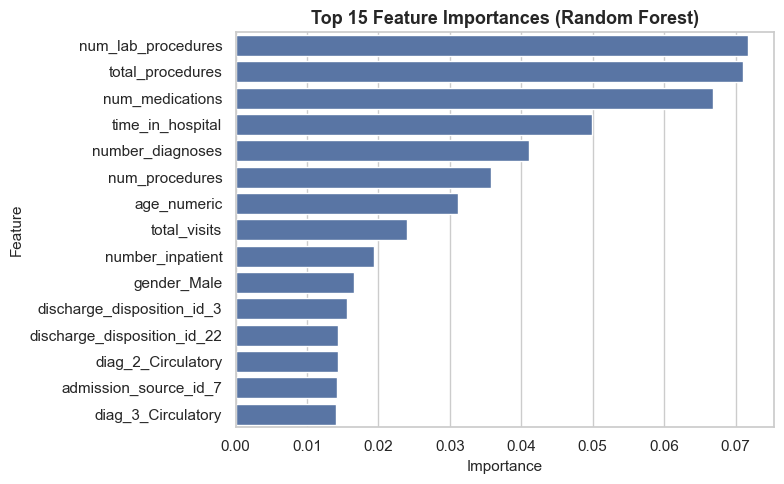

In [187]:

import pandas as pd

importances = rf_model.feature_importances_
features = X_train_clf_encoded.columns

feat_imp = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

# Show top 15 features
display(feat_imp.head(15))


plt.figure(figsize=(8, 5))
sns.barplot(data=feat_imp.head(15), x="Importance", y="Feature")
plt.title("Top 15 Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

#### Interpretation
The Random Forest feature importance analysis identifies which variables contributed most to the model’s predictions.

Compared to correlation analysis, feature importance can capture non-linear relationships and interactions between variables. The most important features are mainly related to hospital utilization, treatment intensity, and patient history, which is consistent with the EDA and correlation analysis.

#### Naive Bayes


--- Naive Bayes ---
Accuracy: 22.66%
Weighted F1 Score: 0.1531

Classification Report:

              precision    recall  f1-score   support

         <30       0.12      0.00      0.00       509
         >30       0.18      0.99      0.31      2265
          NO       0.96      0.07      0.13     10135

    accuracy                           0.23     12909
   macro avg       0.42      0.35      0.15     12909
weighted avg       0.79      0.23      0.15     12909



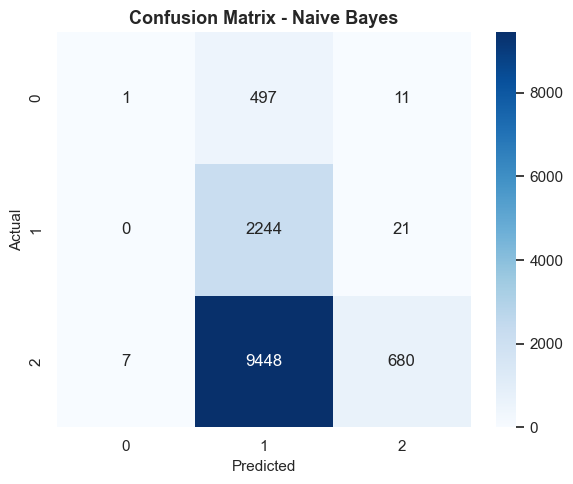

In [188]:
nb_model = GaussianNB()

acc_nb, f1_nb, y_pred_nb = run_evaluate_model(
    nb_model,
    "Naive Bayes",
    X_train_clf_encoded,
    X_test_clf_encoded,
    y_train_clf,
    y_test_clf
)

#### 6.6 Compare Models

,Model,Accuracy (%),F1 Score
3,Random Forest,75.017430,0.729987
0,KNN,78.503370,0.694007
1,Linear SVM,78.511116,0.690601
2,Decision Tree,48.136959,0.545637
4,Naive Bayes,22.658610,0.153070


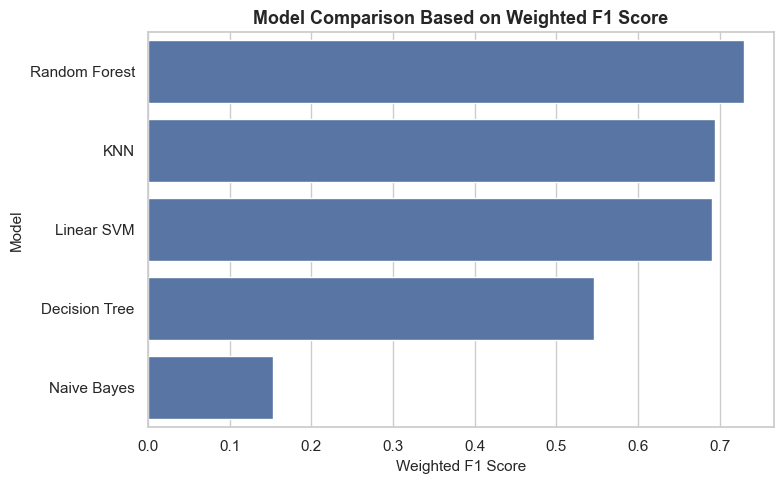

In [189]:
results = pd.DataFrame({
    "Model": [
        "KNN",
        "Linear SVM",
        "Decision Tree",
        "Random Forest",
        "Naive Bayes"
    ],
    "Accuracy (%)": [
        acc_knn,
        acc_svm,
        acc_tree,
        acc_rf,
        acc_nb
    ],
    "F1 Score": [
        f1_knn,
        f1_svm,
        f1_tree,
        f1_rf,
        f1_nb
    ]
})

results = results.sort_values(by="F1 Score", ascending=False)

display(results)

plt.figure(figsize=(8, 5))
sns.barplot(data=results, x="F1 Score", y="Model")
plt.title("Model Comparison Based on Weighted F1 Score")
plt.xlabel("Weighted F1 Score")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

Models were compared using weighted F1-score because the readmission classes are imbalanced.

The best-performing model was selected based on its ability to balance performance across all classes rather than only maximizing overall accuracy.

#### 6.7 Best Model Analysis
Let’s analyze the best-performing model.

Best model: Random Forest


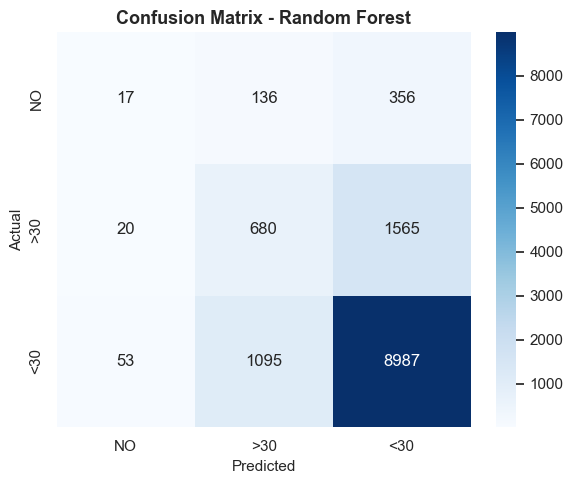

Classification Report:

              precision    recall  f1-score   support

         <30       0.19      0.03      0.06       509
         >30       0.36      0.30      0.33      2265
          NO       0.82      0.89      0.85     10135

    accuracy                           0.75     12909
   macro avg       0.46      0.41      0.41     12909
weighted avg       0.72      0.75      0.73     12909



In [190]:
best_model_name = results.iloc[0]["Model"]

if best_model_name == "KNN":
    y_pred_best = y_pred_knn
elif best_model_name == "Linear SVM":
    y_pred_best = y_pred_svm
elif best_model_name == "Decision Tree":
    y_pred_best = y_pred_tree
elif best_model_name == "Random Forest":
    y_pred_best = y_pred_rf
else:
    y_pred_best = y_pred_nb

print("Best model:", best_model_name)

cm = confusion_matrix(y_test_clf, y_pred_best)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['NO', '>30', '<30'],
            yticklabels=['NO', '>30', '<30'])
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

print("Classification Report:\n")
print(classification_report(y_test_clf, y_pred_best, zero_division=0))

#### Decision Tree Visualization
A visualization of the decision tree was generated to understand how the model makes decisions.

Due to the high dimensionality of the dataset, only the first few levels of the tree were displayed. These levels represent the most important decision rules used by the model.

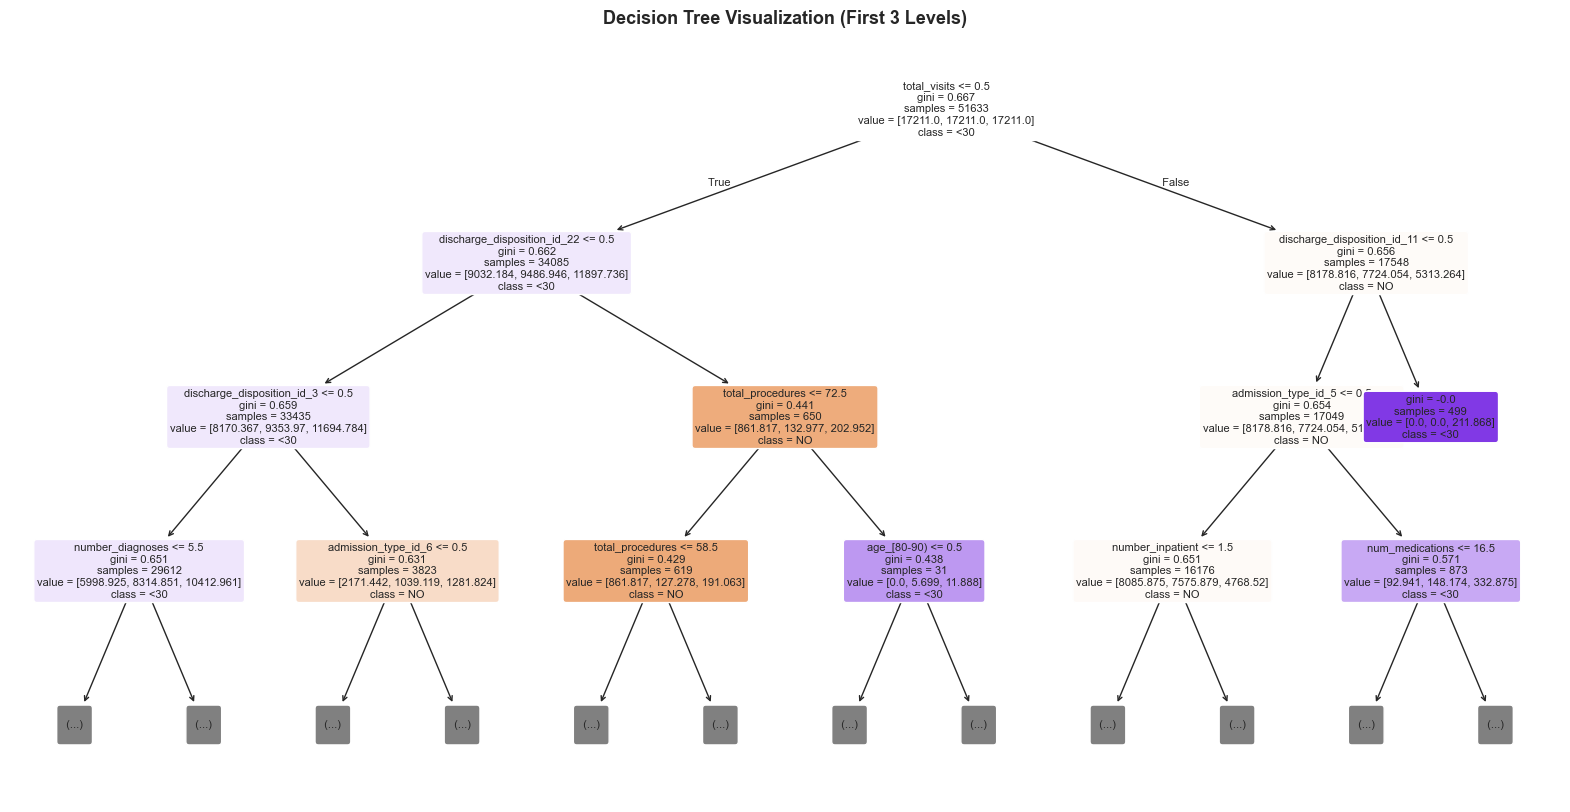

In [191]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))

plot_tree(
    tree_model,
    max_depth=3,
    feature_names=X_train_clf_encoded.columns,
    class_names=['NO', '>30', '<30'],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title("Decision Tree Visualization (First 3 Levels)")
plt.show()

#### 6.8 Classification Conclusion

The classification models were evaluated using both accuracy and weighted F1-score, with greater emphasis on the F1-score due to the class imbalance in the readmission variable.

Among the tested models, tree-based approaches such as Random Forest and Decision Tree achieved the best performance. This is expected, as these models are capable of capturing complex and non-linear relationships within the data.

K-Nearest Neighbors (KNN) showed lower performance, which can be explained by the high-dimensional feature space created after one-hot encoding. Distance-based models are less effective in such sparse representations.

Linear SVM provided stable performance but was limited in capturing complex patterns compared to tree-based models.

Overall, the classification performance is moderate. This is expected given the nature of the dataset, which includes class imbalance, high dimensionality, and relatively weak relationships between some features and the target variable.

Despite these challenges, the models were able to identify meaningful patterns, particularly from features related to hospital utilization, patient complexity, and clinical measurements.

## Binary Classification

A binary classification version of the problem was also tested by grouping readmitted patients (>30 and <30) into a single category.

This simplified the prediction task and resulted in higher accuracy. However, the multiclass approach was retained as the primary task because it provides more detailed clinical insight by distinguishing early and late readmissions.

#### Binary target

In [192]:
# Binary target: 0 = NO, 1 = READMITTED
df['readmitted_binary'] = df['readmitted'].apply(lambda x: 0 if x == 'NO' else 1)

y_bin = df['readmitted_binary']
X_bin = df.drop(columns=['readmitted', 'readmitted_binary'])

#### Train-Test Split

In [193]:
X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(
    X_bin,
    y_bin,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_bin
)

#### Encoding


In [194]:
categorical_features = X_train_bin.select_dtypes(include=["object"]).columns.tolist()

X_train_bin_enc = pd.get_dummies(X_train_bin, columns=categorical_features, drop_first=True)
X_test_bin_enc = pd.get_dummies(X_test_bin, columns=categorical_features, drop_first=True)

X_train_bin_enc, X_test_bin_enc = X_train_bin_enc.align(
    X_test_bin_enc, join="left", axis=1, fill_value=0
)

C:\Users\User\AppData\Local\Temp\ipykernel_30924\2625000262.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train_bin.select_dtypes(include=["object"]).columns.tolist()


#### Scaling

In [195]:
scaler = StandardScaler(with_mean=False)

X_train_bin_scaled = scaler.fit_transform(X_train_bin_enc)
X_test_bin_scaled = scaler.transform(X_test_bin_enc)

#### Random Forest Model Training

In [196]:
rf_bin = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=10,
    min_samples_leaf=3,
    class_weight="balanced",
    n_jobs=-1,
    random_state=RANDOM_STATE
)

rf_bin.fit(X_train_bin_enc, y_train_bin)

y_pred_bin = rf_bin.predict(X_test_bin_enc)

#### Binary Model Evaluation

Binary Accuracy: 75.95%
Binary F1 Score: 0.3533

Classification Report:

              precision    recall  f1-score   support

           0       0.82      0.88      0.85     10135
           1       0.42      0.31      0.35      2774

    accuracy                           0.76     12909
   macro avg       0.62      0.59      0.60     12909
weighted avg       0.74      0.76      0.75     12909



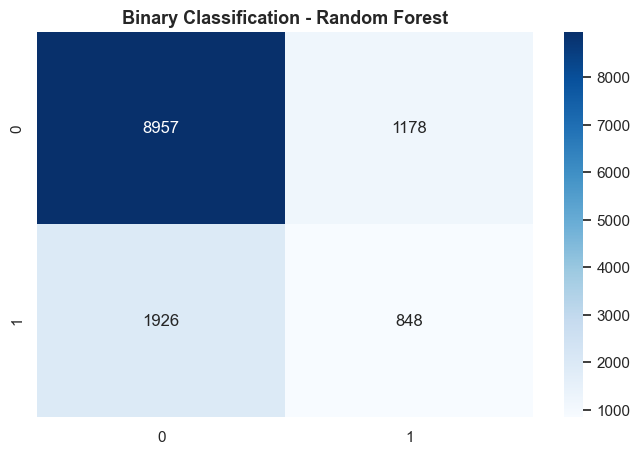

In [197]:
acc_bin = accuracy_score(y_test_bin, y_pred_bin) * 100
f1_bin = f1_score(y_test_bin, y_pred_bin)

print(f"Binary Accuracy: {acc_bin:.2f}%")
print(f"Binary F1 Score: {f1_bin:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test_bin, y_pred_bin))

cm = confusion_matrix(y_test_bin, y_pred_bin)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Binary Classification - Random Forest")
plt.show()


#### Interpretation
The binary classification model was evaluated using accuracy and F1-score.

Binary classification achieved higher performance than multiclass classification because the prediction task was simplified by grouping `<30` and `>30` readmissions into one class.

However, this simplification removes the distinction between early and late readmissions. Therefore, the multiclass model remains the main task because it provides more clinically detailed information.

### Step-7- Regression Modeling
We now build models to predict the time spent in the hospital category (time_in_hospital).

#### 7.0 Import the libraries

In [198]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder,  StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score

#### 7.1 Prepare Features and Target

We separate features (X) and target (y), we make sure the target is correctly defined and we prepare the dataset for modeling

In [199]:
y_reg = df["time_in_hospital"]
X_reg = df.drop(columns=["readmitted", "readmitted_binary", "time_in_hospital"])

print("Feature matrix shape:", X_reg.shape)
print("Target shape:", y_reg.shape)
print("\nTarget distribution:")
print(y_reg.value_counts())

Feature matrix shape: (64542, 47)
Target shape: (64542,)

Target distribution:
time_in_hospital
3     11548
2     11203
1      9784
4      8802
5      6320
6      4685
7      3589
8      2585
9      1746
10     1335
11     1040
12      767
13      651
14      487
Name: count, dtype: int64


#### 7.2 Train-Test Split

Split dataset into training and testing sets.

In [200]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

print("Training set size:", X_train_reg.shape)
print("Testing set size:", X_test_reg.shape)

Training set size: (51633, 47)
Testing set size: (12909, 47)


#### 7.3 Encode Categorical Features
Categorical variables were encoded using mean (target) encoding, where each category is replaced by the average value of the target variable.

This approach allows the model to capture the relationship between categorical features and the target while avoiding the creation of many additional columns.

The encoding was computed using training data only and then applied to the test set to prevent data leakage.

In [201]:
# Copy datasets so we don't modify the original data
X_train_reg_encoded = X_train_reg.copy()
X_test_reg_encoded = X_test_reg.copy()

categorical_features_reg = X_train_reg.select_dtypes(include=["object"]).columns.tolist()

# Apply mean (target) encoding
for col in categorical_features_reg:
    
    # Compute mean target per category only in train
    mean_values = y_train_reg.groupby(X_train_reg[col]).mean()
    
    # Replace categories in train
    X_train_reg_encoded[col] = X_train_reg[col].map(mean_values)
    
    # Replace categories in test
    X_test_reg_encoded[col] = X_test_reg[col].map(mean_values)
    
    # Handle unseen categories in test
    X_test_reg_encoded[col] = X_test_reg_encoded[col].fillna(y_train_reg.mean())

# Check shapes
print("Encoded training shape:", X_train_reg_encoded.shape)
print("Encoded testing shape:", X_test_reg_encoded.shape)

C:\Users\User\AppData\Local\Temp\ipykernel_30924\150040817.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features_reg = X_train_reg.select_dtypes(include=["object"]).columns.tolist()


Encoded training shape: (51633, 47)
Encoded testing shape: (12909, 47)


#### 7.4 Feature Scaling

In [202]:
scaler_reg = StandardScaler(with_mean=False)

X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg_encoded)
X_test_reg_scaled = scaler_reg.transform(X_test_reg_encoded)

print("Feature scaling completed.")

Feature scaling completed.


#### 7.5 Train Regression Models

We will compare a set of regression algorithms.

We will use:
- Linear-family models
    - Linear Regression
    - Ridge

- Tree-based and ensemble models
    - Random Forest Regressor

### Evaluate model definition

In [203]:
def run_regression_model(model, name, X_train, X_test, y_train, y_test):

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    print(f"\n--- {name} ---")
    print("R2:", r2)
    print("RMSE:", rmse)

    plt.scatter(y_test, y_pred)
    plt.title(f"Actual vs Predicted - {name}")
    plt.show()

    return r2, rmse, y_pred

The regression models were evaluated using RMSE, and R² score to assess prediction accuracy. The results were compared across models, and ranking based on R² score was used to identify the most effective model.

#### Linear Regression
Linear Regression is applied as a baseline model to evaluate how well the features can predict the target variable.


--- Linear Regression ---
R2: 0.3753131672309944
RMSE: 2.2634494138870114


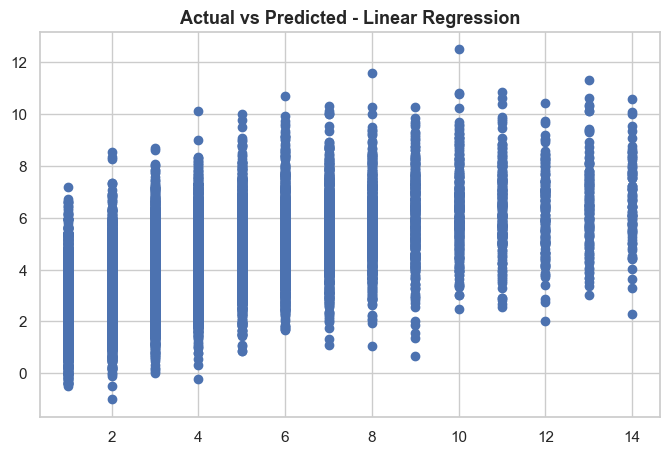

In [204]:
lr_model = LinearRegression()

r2_lr, rmse_lr, y_pred_lr = run_regression_model(
    lr_model,
    "Linear Regression",
    X_train_reg_scaled,
    X_test_reg_scaled,
    y_train_reg,
    y_test_reg
)

#### Ridge
Ridge Regression is used to improve Linear Regression by reducing overfitting through regularization.


--- Ridge Regression ---
R2: 0.3753133906923164
RMSE: 2.2634490090494057


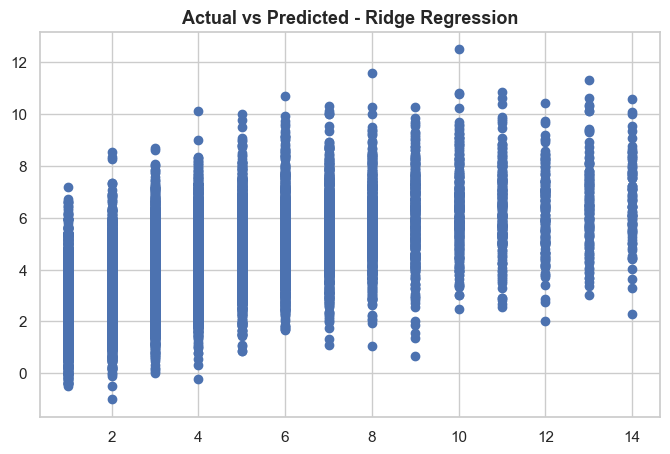

In [205]:
ridge_model = Ridge(alpha=1.0)

r2_ridge, rmse_ridge, y_pred_ridge = run_regression_model(
    ridge_model,
    "Ridge Regression",
    X_train_reg_scaled,
    X_test_reg_scaled,
    y_train_reg,
    y_test_reg
)

#### Random forest
Random Forest is used as an ensemble model that combines multiple decision trees to improve prediction accuracy and capture complex patterns in the data. 


--- Random Forest ---
R2: 0.42521385923034216
RMSE: 2.171164657243174


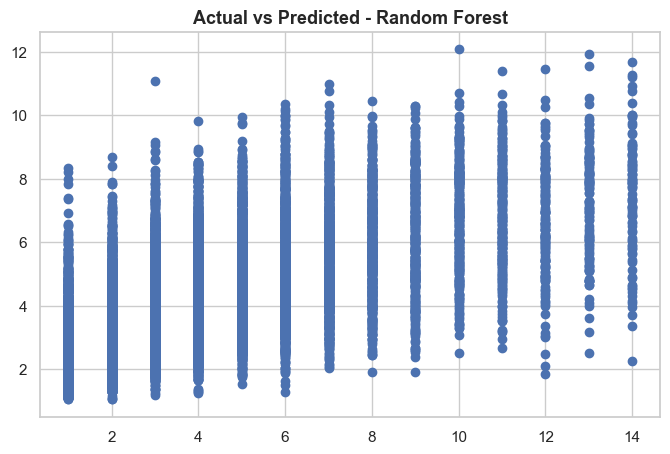

In [206]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_split=10,
    min_samples_leaf=3,
    n_jobs=-1,
    random_state=RANDOM_STATE
)

r2_rf, rmse_rf, y_pred_rf = run_regression_model(
    rf_model,
    "Random Forest",
    X_train_reg_encoded,
    X_test_reg_encoded,
    y_train_reg,
    y_test_reg
)

#### 7.7 Compare Models

In [207]:
results_reg = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Random Forest"
    ],
    "R2 Score": [
        r2_lr,
        r2_ridge,
        r2_rf
    ],
    "RMSE": [
        rmse_lr,
        rmse_ridge,
        rmse_rf
    ]
})

# Sort by best model, meaning highest R2 score
results_reg = results_reg.sort_values(by="R2 Score", ascending=False)

display(results_reg)

,Model,R2 Score,RMSE
2,Random Forest,0.425214,2.171165
1,Ridge Regression,0.375313,2.263449
0,Linear Regression,0.375313,2.263449


#### 7.8 Best Model Analysis
Now we analyze the best-performing model.

##### Get Best Model

Best model: Random Forest
R2 Score: 0.42521385923034216
RMSE: 2.171164657243174


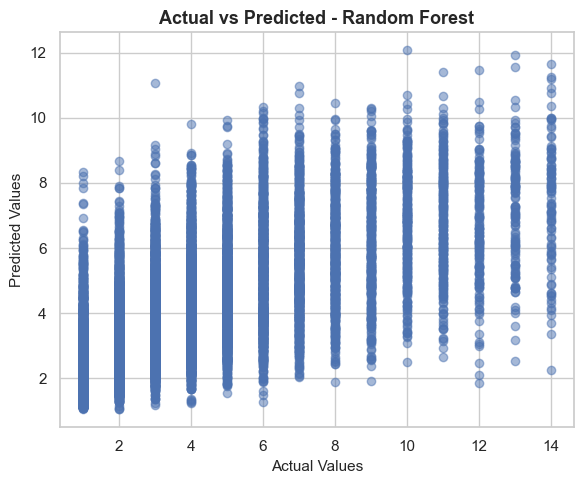

In [208]:
best_model_name = results_reg.iloc[0]["Model"]

if best_model_name == "Linear Regression":
    y_pred_best = y_pred_lr
elif best_model_name == "Ridge Regression":
    y_pred_best = y_pred_ridge
else:
    y_pred_best = y_pred_rf

print("Best model:", best_model_name)
print("R2 Score:", r2_score(y_test_reg, y_pred_best))
print("RMSE:", np.sqrt(mean_squared_error(y_test_reg, y_pred_best)))

plt.figure(figsize=(6, 5))
plt.scatter(y_test_reg, y_pred_best, alpha=0.5)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title(f"Actual vs Predicted - {best_model_name}")
plt.tight_layout()
plt.show()

#### 7.9 Regression Conclusion

The regression models were evaluated using R² score and RMSE.

Random Forest achieved the best performance, showing its ability to capture complex and non-linear relationships in the data.

Linear Regression and Ridge Regression produced similar results, suggesting that regularization did not significantly improve performance for this dataset.

Overall, the regression performance is moderate, which indicates that hospital length of stay is influenced by several complex factors that may not be fully captured by the available features.